# Pipeline: stacked signals per step
One plot per step (raw, processed, analytic), three ROI signals stacked vertically.

In [60]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset import load_mat_data, fft_bandpass_3d, hilbert_transform
from src.models import CoupledHopfModel

def _to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    return x.detach().cpu().numpy()

plt.rcParams["figure.dpi"] = 140
%matplotlib inline

In [20]:
dataset_path = project_root / "data" / "ts_young" / "ts_young_TR0.72.mat"
subject_index = 0
roi_indices = [0, 49, 99]
dt = 0.72
f_lo, f_hi = 0.008, 0.08
max_timepoints = 200
w, h = 3.2, 2.0

data = load_mat_data(str(dataset_path))
raw_timeseries = data["timeseries_all"].transpose(2, 0, 1)

ts = torch.as_tensor(raw_timeseries)
time = np.arange(max_timepoints, dtype=np.float32) * dt

subject_ts = ts[subject_index : subject_index + 1]
mean = subject_ts.mean(dim=2, keepdim=True)
std = subject_ts.std(dim=2, keepdim=True) + 1e-8
normalized = (subject_ts - mean) / std

filtered_t = fft_bandpass_3d(normalized, dt=dt, f_lo=f_lo, f_hi=f_hi)
analytic_t = hilbert_transform(filtered_t)

raw = _to_numpy(normalized[0, :, :max_timepoints])
processed = _to_numpy(filtered_t[0, :, :max_timepoints])
analytic = _to_numpy(analytic_t[0, :, :max_timepoints])

In [62]:
out_dir_png = project_root / "paper" / "images_png" / "representation"
out_dir_svg = project_root / "paper" / "images_svg" / "representation"
out_dir_png.mkdir(parents=True, exist_ok=True)
out_dir_svg.mkdir(parents=True, exist_ok=True)



def stacked_plot(signals, filename, signals_imag=None, colors="blues"):
    """signals: (n_rois_selected, n_time) real-valued array.

    If signals_imag is provided, it is overlaid as a dashed line per ROI.
    """
    cmap = plt.cm.Blues if colors == "blues" else plt.cm.Reds
    colors = cmap(np.linspace(0.5, 1.0, len(roi_indices)))

    amps = [np.max(np.abs(s)) for s in signals]
    if signals_imag is not None:
        amps += [np.max(np.abs(s)) for s in signals_imag]
    
    spacing = 2.2 * max(amps)
    offsets = [spacing * (len(signals) - 1 - i) for i in range(len(signals))]
    # Your extra gap for the dots
    offsets[-1] -= spacing * 0.7

    fig, ax = plt.subplots(figsize=(w, h))
    fig.patch.set_alpha(0.0)

    for i, s in enumerate(signals):
        ax.plot(time, s + offsets[i], color=colors[i], linewidth=1.2, alpha=1.0)
        if signals_imag is not None:
            ax.plot(
                time,
                signals_imag[i] + offsets[i],
                color=colors[i],
                linewidth=1.2,
                alpha=1.0,
                linestyle="--",
            )

    # --- ADDED CODE: 3 Vertical Dots ---
    if len(signals) >= 2:
        # X-coordinate: Place in the middle of the time axis
        mid_x = (time[0] + time[-1]) / 2.0 
        
        # Y-coordinates: 3 evenly spaced points in the gap between the last two offsets
        dot_ys = np.linspace(offsets[-1] + spacing * 0.65, offsets[-2] - spacing * 0.65, 3)
        
        # Plot the dots
        ax.plot([mid_x] * 3, dot_ys, 'o', color='k', markersize=1, zorder=3)
    # -----------------------------------

    y_min = -spacing * 0.6 - spacing * 0.7
    y_max = offsets[0] + spacing * 0.6
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(time[0], time[-1])

    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)

    x_span = time[-1] - time[0]
    ax.plot(
        [time[0], time[0]], [y_min, y_max],
        color="black", lw=1.0, solid_capstyle="butt", clip_on=False,
    )
    ax.annotate(
        "",
        xy=(time[-1] + 0.04 * x_span, y_min),
        xytext=(time[0], y_min),
        arrowprops=dict(arrowstyle="->", color="black", lw=1.0,
                        shrinkA=0, shrinkB=0),
        annotation_clip=False,
    )

    ax.set_xlabel("Time", labelpad=8)

    fig.savefig(out_dir_png / f"{filename}.png", dpi=200, bbox_inches="tight")
    fig.savefig(out_dir_svg / f"{filename}.svg", bbox_inches="tight")
    plt.show()
    return fig

## Step 1: raw data

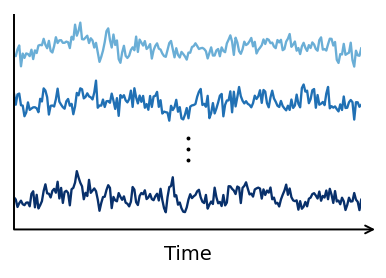

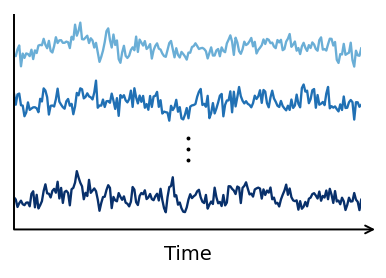

In [56]:
raw_signals = np.stack([raw[roi] for roi in roi_indices])
stacked_plot(raw_signals, "stacked_raw")

## Step 2: processed data

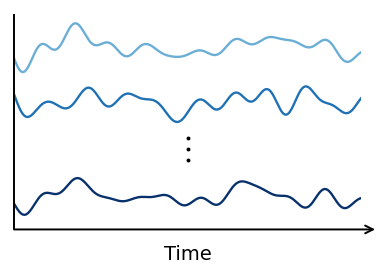

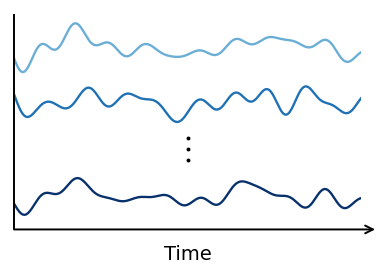

In [57]:
processed_signals = np.stack([processed[roi] for roi in roi_indices])
stacked_plot(processed_signals, "stacked_processed")

## Step 3: analytic data

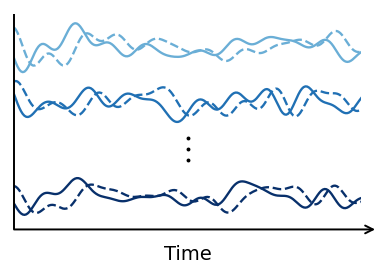

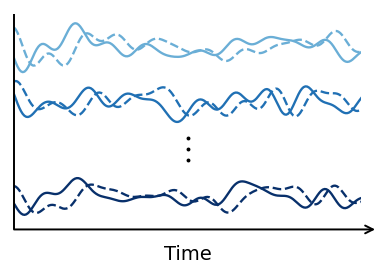

In [58]:
analytic_real = np.stack([analytic[roi].real for roi in roi_indices])
analytic_imag = np.stack([analytic[roi].imag for roi in roi_indices])
stacked_plot(analytic_real, "stacked_analytic", signals_imag=analytic_imag)

## Step 4: Hopf model output

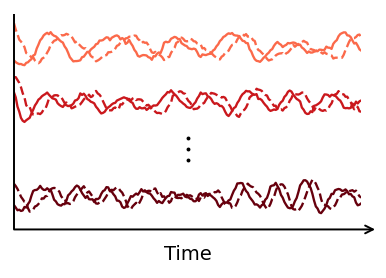

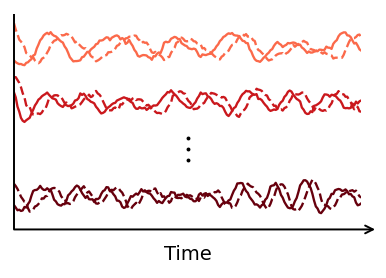

In [63]:
torch.manual_seed(0)
model = CoupledHopfModel(
    n_rois=analytic.shape[0],
    initial_a=-0.02,
    initial_g=1.0,
    initial_kappa=0.1,
    noise_sigma=0.1,
)
initial_state = torch.tensor(analytic[:, 0])[None]
with torch.no_grad():
    sim = model.forward(initial_state=initial_state, n_steps=max_timepoints)
sim = _to_numpy(sim[0])

sim_real = np.stack([sim[roi].real for roi in roi_indices])
sim_imag = np.stack([sim[roi].imag for roi in roi_indices])
stacked_plot(sim_real, "stacked_hopf", signals_imag=sim_imag, colors="reds")